# Data Science Project 3: Customer Segmentation (Unsupervised Learning)

## Phase 1: Data Preparation & Scaling

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading & Initial Inspection

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep = "\t")

In [3]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

<Axes: xlabel='Income'>

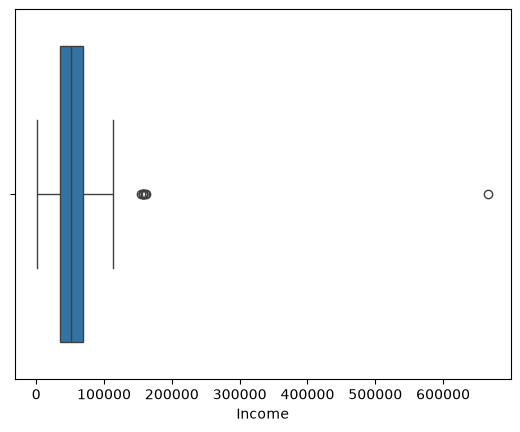

In [6]:
sns.boxplot(x = df["Income"])

### Handling Missing Values

In [7]:
df["Income"] = df['Income'].fillna(df['Income'].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

### Outlier Detection & Removal (IQR Method)

In [9]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

In [10]:
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 35538.75
Q3: 68289.75
IQR: 32751.0


In [11]:
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("upper_bound:", upper_bound)
print("lower_bound:", lower_bound)

upper_bound: 117416.25
lower_bound: -13587.75


In [12]:
df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]
print(df.shape)

(2232, 29)


### Dropping Irrelevant Columns

In [13]:
df = df.drop(columns = ["ID", "Z_CostContact", "Z_Revenue"])

In [14]:
df.shape

(2232, 26)

### Selecting Numeric Features

In [15]:
numeric_df = df.select_dtypes(include = ["int64", "float64"])
print(numeric_df.shape)

(2232, 23)


In [16]:
numeric_df.columns.tolist()

['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Response']

### Feature Scaling (StandardScaler)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

In [18]:
print(scaled_data.mean(axis = 0))
print(scaled_data.std(axis = 0))

[ 6.39313373e-15 -1.16195385e-16 -6.36687039e-18  1.01869926e-16
 -1.03063714e-16 -3.74053636e-17  3.02426344e-17 -6.04852687e-17
 -1.67130348e-17  6.04852687e-17 -7.16272919e-17 -5.25266807e-17
 -1.20970537e-16 -6.68521391e-17 -1.59171760e-18  6.68521391e-17
  1.75088936e-17  8.75444679e-18  1.59171760e-17 -1.43254584e-17
  2.06923288e-17  2.38757640e-17  4.45680927e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Phase 2: Dimensionality Reduction (PCA)

### Understanding Variance Distribution (Full PCA)

In [19]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(scaled_data)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [20]:
print(pca_full.explained_variance_ratio_)

[0.29761353 0.08889825 0.08238603 0.06123344 0.04773393 0.0444643
 0.04284258 0.03694518 0.03259302 0.02982039 0.02860362 0.0264858
 0.02475785 0.02410641 0.02254017 0.01893038 0.01806865 0.01667076
 0.0159173  0.01353995 0.01135823 0.00853999 0.00595024]


### Cumulative Explained Variance Analysis

In [21]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print(cumulative_variance)

[0.29761353 0.38651178 0.4688978  0.53013124 0.57786517 0.62232947
 0.66517206 0.70211723 0.73471026 0.76453064 0.79313426 0.81962006
 0.84437791 0.86848431 0.89102449 0.90995487 0.92802352 0.94469428
 0.96061159 0.97415153 0.98550977 0.99404976 1.        ]


### Applying PCA (Reduced to 3 Components)

In [22]:
pca = PCA(n_components = 3)
pca_data = pca.fit_transform(scaled_data)

### Verifying Variance Captured

In [23]:
print(pca_data.shape)
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

(2232, 3)
[0.29761353 0.08889825 0.08238603]
0.4688978040277355


## Phase 3: K-Means Clustering

### Finding Optimal K (Elbow Method)

In [26]:
from sklearn.cluster import KMeans

In [37]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

In [38]:
print(wcss)

[24071.337667567834, 12197.649363879042, 8609.500489433314, 6342.450039369942, 5502.303861694743, 4822.222864252338, 4432.898354840918, 4038.999455584204, 3575.0956764486664, 3336.485621750564]


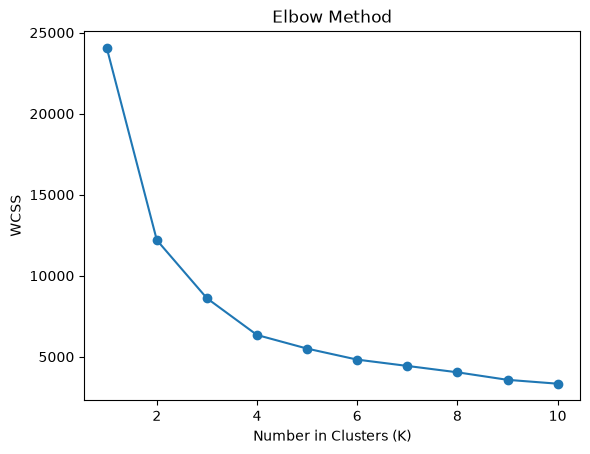

In [39]:
plt.plot(range(1,11), wcss, marker = "o")
plt.xlabel("Number in Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Validating K (Silhouette Score)

In [41]:
from sklearn.metrics import silhouette_score


silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[0.47317553941420387, 0.4280129586695407, 0.44284742304988134, 0.352145287544075, 0.33371534378578466, 0.3335063067421819, 0.32831512526970585, 0.33441398670581907, 0.3229469424280951]


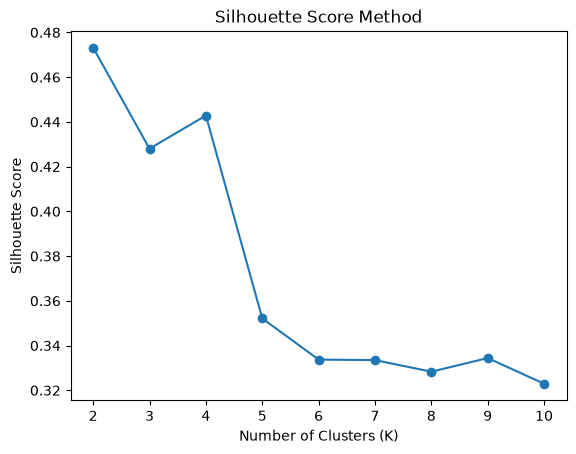

In [42]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.show()

### Applying K-Means Model

In [43]:
kmeans_final = KMeans(n_clusters = 4, random_state = 42)
cluster_labels = kmeans_final.fit_predict(pca_data)

In [44]:
df['Cluster'] = cluster_labels
df['Cluster'].value_counts()

Cluster
1    1007
0     597
2     483
3     145
Name: count, dtype: int64

### Visualizing Clusters

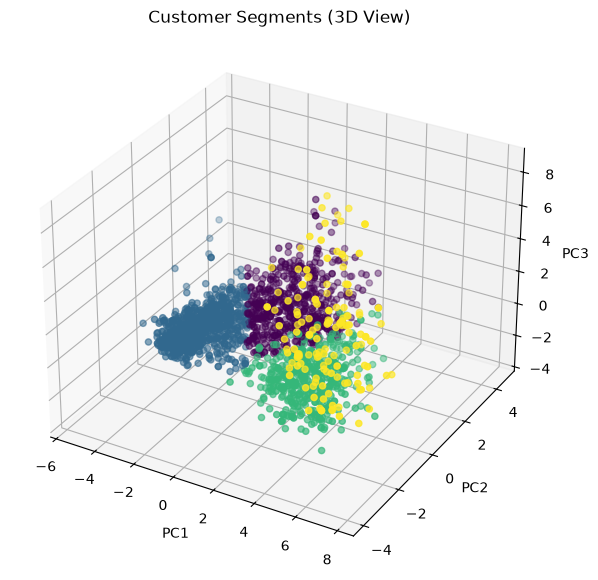

In [45]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(pca_data[:, 0], pca_data[:, 1], pca_data[:, 2], c=cluster_labels, cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Customer Segments (3D View)')
plt.show()

## Phase 4: Translating Clusters into Business Personas

### Analyzing Cluster Characteristics

In [47]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

          Year_Birth        Income   Kidhome  Teenhome    Recency    MntWines  \
Cluster                                                                         
0        1963.608040  57184.652429  0.247906  0.963149  48.705193  440.968174   
1        1972.131082  34012.153426  0.809335  0.424032  49.061569   39.438928   
2        1967.598344  72678.448240  0.047619  0.227743  51.144928  512.018634   
3        1970.931034  81014.224138  0.041379  0.137931  44.351724  898.800000   

         MntFruits  MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
Cluster                                                                 ...   
0        19.440536       125.492462        26.380235         19.948074  ...   
1         5.011917        23.256207         7.248262          5.130089  ...   
2        71.289855       422.875776       102.308489         71.971014  ...   
3        53.758621       457.972414        79.724138         60.510345  ...   

         NumCatalogPurchases  NumStore

### 4.2 Business Persona Summary

| Cluster | Persona Name | Key Traits | Business Action |
|---------|-------------|------------|------------------|
| 3 | The Premium Loyalists | Highest income (~81k), highest spending, 75% campaign response rate | Exclusive VIP treatment, early access, loyalty programs |
| 2 | The Affluent Explorers | High income (~73k), high spending, few/no kids | Cross-sell & upsell premium products via catalog/store |
| 0 | The Steady Moderates | Balanced income & spending across categories | Value-based offers, bundle deals to move toward higher tiers |
| 1 | The Budget-Conscious Families | Lowest income (~34k), most kids, lowest spending, low campaign response | Discount-driven marketing, family-value bundles |